# BÁO CÁO TIẾN ĐỘ ĐỒ ÁN - TUẦN 1 & 2

**Đề tài:** Phân loại câu hỏi  (bộ dữ liệu TREC)

## 1. Phân tích bài toán và Tìm hiểu Dataset
* **Mục tiêu:** Xây dựng hệ thống phân loại câu hỏi (Question Classification) vào 6 lớp đối tượng chính.
* **Dataset sử dụng:** **TREC Question Classification**.
* **Các lớp (Labels) cần phân loại:**
    1.  **ABBR**: Câu hỏi về từ viết tắt.
    2.  **DESC**: Câu hỏi yêu cầu mô tả, định nghĩa.
    3.  **ENTY**: Câu hỏi về thực thể (động vật, vật thể...).
    4.  **HUM**: Câu hỏi về con người hoặc tổ chức.
    5.  **LOC**: Câu hỏi về địa điểm, vị trí.
    6.  **NUM**: Câu hỏi về con số, ngày tháng.

In [2]:


# Install thu vien (chạy lần đầu)
#!pip install -q tensorflow numpy pandas scikit-learn matplotlib seaborn requests

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import re

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


# 1. LOAD VÀ TIỀN XỬ LÝ DỮ LIỆU TREC

In [3]:




def load_trec_data():
    """Download và load TREC dataset"""
    print("Downloading TREC dataset...")
    train_url = "https://cogcomp.seas.upenn.edu/Data/QA/QC/train_5500.label"
    test_url = "https://cogcomp.seas.upenn.edu/Data/QA/QC/TREC_10.label"
   # sử dụng thư viện request để  load dữ liệu TREC từ nguồn online. Dataset TREC được host trên server của University of Pennsylvania
# nếu hỏi ở đây làm sao có sẵn vtaapj train test mà ko tự chia

    try:
        train_data = requests.get(train_url).text.strip().split('\n')
        test_data = requests.get(test_url).text.strip().split('\n')
    except:
        print("Error downloading. Using alternative source...")
        # Fallback URLs
        train_url = "http://cogcomp.seas.upenn.edu/Data/QA/QC/train_5500.label"
        test_url = "http://cogcomp.seas.upenn.edu/Data/QA/QC/TREC_10.label"
        train_data = requests.get(train_url).text.strip().split('\n')
        test_data = requests.get(test_url).text.strip().split('\n')

    def parse_line(line):
        parts = line.split(' ', 1)# tách cụm đầu tiên trong chuõi ra thành label và phần còn lại là question
        if len(parts) == 2:
            label = parts[0].split(':')[0] # lấy course label từ chữ đứng truocws :
            question = parts[1] # phần câu hỏi là phần sau
            return label, question # trả về label và câu hỏi
        return None, None


    # tách nhãn với câu hỏi ra ở tập train
    train_labels, train_questions = [], []
    for line in train_data:
        label, question = parse_line(line)
        if label and question:
            train_labels.append(label)
            train_questions.append(question)
# tách nhãn câu hỏi tập test ra
    test_labels, test_questions = [], []
    for line in test_data:
        label, question = parse_line(line)
        if label and question:
            test_labels.append(label)
            test_questions.append(question)

    return train_questions, train_labels, test_questions, test_labels

#tiền xử lí đầu vào
def preprocess_text(text):
    text = text.lower() # Chuyển về chữ thường
    text = re.sub(r'[^a-z0-9\s]', '', text) # Xóa ký tự đặc biệt, chỉ giữ lại chữ và số
    return text
# Load data
X_train, y_train, X_test, y_test = load_trec_data()

# Preprocess
X_train = [preprocess_text(q) for q in X_train]
X_test = [preprocess_text(q) for q in X_test]

print(f"\n Loaded {len(X_train)} training samples")
print(f" Loaded {len(X_test)} test samples")


 Loaded 5452 training samples
 Loaded 500 test samples


In [4]:
X_train, y_train, X_test, y_test = load_trec_data()

# Preprocess
X_train = [preprocess_text(q) for q in X_train]
X_test = [preprocess_text(q) for q in X_test]

print(f"\n Loaded {len(X_train)} training samples")
print(f" Loaded {len(X_test)} test samples")

for x, y in zip(X_train[:5], y_train[:5]):
    print(x, "->", y)


 Loaded 5452 training samples
 Loaded 500 test samples
how did serfdom develop in and then leave russia  -> DESC
what films featured the character popeye doyle  -> ENTY
how can i find a list of celebrities  real names  -> DESC
what fowl grabs the spotlight after the chinese year of the monkey  -> ENTY
what is the full form of com  -> ABBR


In [5]:
def show_info(name, x):
    # shape
    if hasattr(x, "shape"):
        shape = x.shape
    elif hasattr(x, "__len__"):
        shape = (len(x),)
    else:
        shape = "unknown"

    # dtype
    if hasattr(x, "dtype"):
        dtype = x.dtype
    else:
        # list hoặc object khác
        dtype = type(x)

    print(f"{name}: shape={shape}, dtype={dtype}")


show_info("X_train", X_train)
show_info("y_train", y_train)
show_info("X_test", X_test)
show_info("y_test", y_test)

X_train: shape=(5452,), dtype=<class 'list'>
y_train: shape=(5452,), dtype=<class 'list'>
X_test: shape=(500,), dtype=<class 'list'>
y_test: shape=(500,), dtype=<class 'list'>


# 2. Đầu vào bài toán

In [ ]:
# 2. TOKENIZATION VÀ PADDING


# Cấu hình tham số
MAX_WORDS = 10000
MAX_LEN = 64


print(f"\n Tokenizing với MAX_LEN={MAX_LEN}...")


tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')

tokenizer.fit_on_texts(X_train_split)


X_train_seq = tokenizer.texts_to_sequences(X_train_split)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)


X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post')

vocab_size = min(len(tokenizer.word_index) + 1, MAX_WORDS)

print(f" Vocabulary size: {vocab_size}")

# vocab size thuc te luc nay la 7k7, set 10k để đảm bảo không bị mất từ nếu test trên 1 dataset mới có đủ chỗ cho từ mới



 Tokenizing với MAX_LEN=64...
 Vocabulary size: 7762


# 3.1 chia tập train/validation/test


## 3.1. Chia tập dữ liệu (Dataset Splitting)
Để đảm bảo mô hình được huấn luyện và đánh giá một cách khách quan, chia tập dữ liệu gốc thành 3 phần riêng biệt theo yêu cầu của đồ án:

* **Tập Train (4,361 mẫu):** Sử dụng để tối ưu hóa trọng số của mô hình CNN. (80%)
* **Tập Validation (1,091 mẫu):** Sử dụng để kiểm chứng hiệu năng trong lúc huấn luyện và điều chỉnh các siêu tham số.(20%)
* **Tập Test (500 mẫu):** Tập dữ liệu độc lập hoàn toàn dùng để đưa ra đánh giá cuối cùng về độ chính xác.

> **Ghi chú:** Chúng em sử dụng tham số `stratify` để đảm bảo tỷ lệ các lớp trong tập Train và Validation được giữ nguyên so với dữ liệu gốc.

In [ ]:

# 2. PHÂN TÍCH DỮ LIỆU


# encode label
label_map = {'ABBR': 0, 'DESC': 1, 'ENTY': 2, 'HUM': 3, 'LOC': 4, 'NUM': 5}
label_names = ['ABBR', 'DESC', 'ENTY', 'HUM', 'LOC', 'NUM']
label_descriptions = {
    'ABBR': 'Abbreviation (Từ viết tắt)',
    'DESC': 'Description (Mô tả)',
    'ENTY': 'Entity (Thực thể)',
    'HUM': 'Human (Con người)',
    'LOC': 'Location (Địa điểm)',
    'NUM': 'Numeric (Số học)'
}

y_train_encoded = np.array([label_map[label] for label in y_train])
y_test_encoded = np.array([label_map[label] for label in y_test])

# One-hot encoding
y_train_cat = keras.utils.to_categorical(y_train_encoded, num_classes=6)
y_test_cat = keras.utils.to_categorical(y_test_encoded, num_classes=6)

# Split train/validation
X_train_split, X_val, y_train_split, y_val_cat = train_test_split(
    X_train, y_train_cat, test_size=0.15, random_state=42,
    stratify=y_train_encoded
)

print(f"\n Dataset split:")
print(f"   Train: {len(X_train_split)} samples")
print(f"   Validation: {len(X_val)} samples")
print(f"   Test: {len(X_test)} samples")



 Dataset split:
   Train: 4634 samples
   Validation: 818 samples
   Test: 500 samples


# 3.2 Thống kê số lượng mẫu theo lớp/ chuỗi


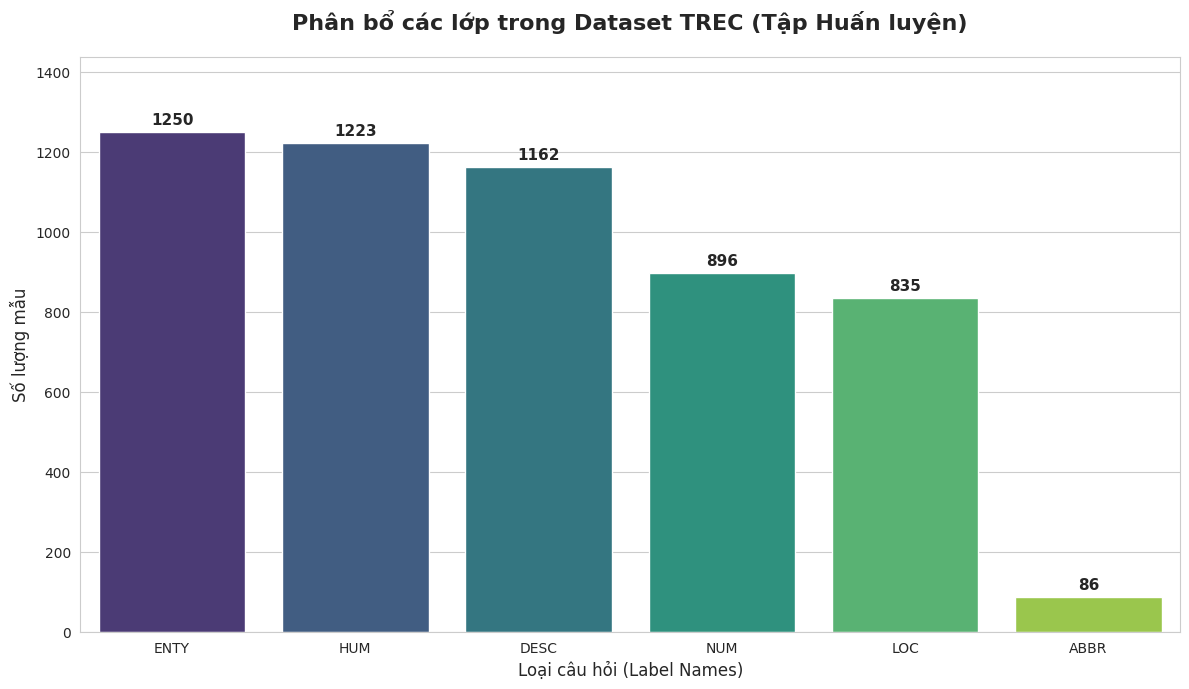

------------------------------
BẢNG THỐNG KÊ CHI TIẾT
------------------------------
ENTY: 1250 mẫu ( 22.9%) - Entity (Thực thể)
HUM: 1223 mẫu ( 22.4%) - Human (Con người)
DESC: 1162 mẫu ( 21.3%) - Description (Mô tả)
NUM:  896 mẫu ( 16.4%) - Numeric (Số học)
LOC:  835 mẫu ( 15.3%) - Location (Địa điểm)
ABBR:   86 mẫu (  1.6%) - Abbreviation (Từ viết tắt)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chuẩn bị dữ liệu cho biểu đồ
unique, counts = np.unique(y_train_encoded, return_counts=True)
dist_df = pd.DataFrame({
    'Loại câu hỏi': [label_names[i] for i in unique],
    'Số lượng': counts,
    'Mô tả': [label_descriptions[label_names[i]] for i in unique]
})

# Sắp xếp theo số lượng giảm dần biểu đồ
dist_df = dist_df.sort_values(by='Số lượng', ascending=False)

# 2. Cấu hình giao diện biểu đồ
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid") # Tạo lưới nền trắng sạch sẽ

# 3. Vẽ biểu đồ cột bằng Seaborn
ax = sns.barplot(
    x='Loại câu hỏi',
    y='Số lượng',
    data=dist_df,
    palette='viridis', # Hệ màu gradient
    hue='Loại câu hỏi',
    legend=False
)

# 4. Thêm các thông số chi tiết trên đầu mỗi cột
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

# 5. Thiết lập tiêu đề và nhãn
plt.title('Phân bổ các lớp trong Dataset TREC (Tập Huấn luyện)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Loại câu hỏi (Label Names)', fontsize=12)
plt.ylabel('Số lượng mẫu', fontsize=12)
plt.ylim(0, max(counts) * 1.15) # Tạo khoảng trống phía trên cho text annotation

plt.tight_layout()
plt.show()

# In ra bảng thống kê chi tiết phía dưới biểu đồ
print("-" * 30)
print("BẢNG THỐNG KÊ CHI TIẾT")
print("-" * 30)
for index, row in dist_df.iterrows():
    percentage = (row['Số lượng'] / len(y_train_encoded)) * 100
    print(f"{row['Loại câu hỏi']}: {row['Số lượng']:4d} mẫu ({percentage:5.1f}%) - {row['Mô tả']}")

### Nhận xét khó khăn đặc thù (Yêu cầu trang 7):
* **Sự mất cân bằng (Data Imbalance):** Có sự chênh lệch lớn về số lượng mẫu giữa các lớp. Lớp ENTY và HUM có số lượng mẫu vượt trội (gần 1000 mẫu), trong khi lớp ABBR chỉ có vỏn vẹn 69 mẫu. Điều này đặt ra vấn đề mô hình phải có khả năng tổng quát hóa tốt để không bị "học lệch".
* **Độ dài chuỗi:** Do đặc thù là câu hỏi (Question), Các câu hỏi trong TREC có đặc điểm là ngắn, súc tích và chứa nhiều từ nghi vấn (Wh-questions). Do đó, em đã thiết lập độ dài đầu vào cố định là L=64 (sử dụng Padding) để bao phủ toàn bộ nội dung của các câu hỏi này mà không làm mất thông tin.



## 4. Xây dựng Mô hình 1 (Baseline): CNN-text (Kim) + CE
Theo yêu cầu tại mục 4 của đồ án, em triển khai mô hình Baseline sử dụng kiến trúc mạng nơ-ron tích chập (CNN) dành cho văn bản của Kim Yoon (2014).

### 4.1. Cấu trúc mạng nơ-ron:(mô hình gồm 6 layers chính)
* **Tầng Embedding:** Chuyển đổi các từ thành vector mật độ cao (Dense Vectors) 100 chiều để máy hiểu ngữ nghĩa.
* **Tầng Convolution (Tích chập):** Sử dụng bộ lọc (filter) kích thước 3 để quét qua văn bản, trích xuất đặc trưng cụm từ (n-grams).
* **Global Max Pooling:** Trích xuất tín hiệu quan trọng nhất từ toàn bộ câu hỏi.
* **Hàm mất mát (Loss Function):** Sử dụng **Cross Entropy (CE)** phù hợp cho bài toán phân loại đa lớp.

### 4.2. Thông số kỹ thuật (Yêu cầu trang 7):
* **Đầu vào (Input):** Câu hỏi đã được tokenized với độ dài cố định $L=64$.
* **Đầu ra (Output):** Xác suất thuộc về $K=6$ lớp nhãn.

In [ ]:
# 5. XÂY DỰNG MÔ HÌNH CNN-TEXT

def build_cnn_model(vocab_size, max_len, embedding_dim=128, num_classes=6):
    """CNN for Text Classification (Kim 2014)"""

    inputs = layers.Input(shape=(max_len,), name='input')

    embedding = layers.Embedding(
        vocab_size,
        embedding_dim,
        input_length=max_len,
        name='embedding'
    )(inputs)

    filter_sizes = [3, 4, 5]
    num_filters = 128
    conv_blocks = []

    for filter_size in filter_sizes:
        conv = layers.Conv1D(
            filters=num_filters,
            kernel_size=filter_size,
            activation='relu',
            name=f'conv_{filter_size}'
        )(embedding)
        pool = layers.GlobalMaxPooling1D(name=f'pool_{filter_size}')(conv)
        conv_blocks.append(pool)

    concatenated = layers.Concatenate(name='concat')(conv_blocks)
    dropout = layers.Dropout(0.5, name='dropout')(concatenated)
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(dropout)

    model = keras.Model(inputs=inputs, outputs=outputs, name='CNN_Text')
    return model

print("\n Building CNN model...")
model = build_cnn_model(vocab_size, MAX_LEN)
model.summary()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


 Building CNN model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "CNN_Text"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 64)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 64, 128)   │    993,536 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_3 (Conv1D)     │ (None, 62, 128)   │     49,280 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_4 (Conv1D)     │ (None, 61, 128)   │     65,664 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_5 (Conv1D)     │ (None, 60, 128)   │     82,048 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_3              │ (None, 128)       │          0 │ conv_3[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_4              │ (None, 128)       │          0 │ conv_4[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_5              │ (None, 128)       │          0 │ conv_5[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 384)       │          0 │ pool_3[0][0],     │
│ (Concatenate)       │                   │            │ pool_4[0][0],     │
│                     │                   │            │ pool_5[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 384)       │          0 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 6)         │      2,310 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,192,838 (4.55 MB)

 Trainable params: 1,192,838 (4.55 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

# 6. TRAINING
print("\n đang chạy, máy cùi thông cảm ....................")
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)
# "EarlyStopping là kỹ thuật để tự động dừng training khi model không còn cải thiện, giúp tiết kiệm thời gian và tránh overfitting."


reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train_pad, y_train_split,
    validation_data=(X_val_pad, y_val_cat),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


 đang chạy, máy cùi thông cảm ....................
Epoch 1/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step - accuracy: 0.3825 - loss: 1.5009 - val_accuracy: 0.7543 - val_loss: 0.7308 - learning_rate: 0.0010
Epoch 2/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.8154 - loss: 0.5523 - val_accuracy: 0.8423 - val_loss: 0.4495 - learning_rate: 0.0010
Epoch 3/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accuracy: 0.9503 - loss: 0.2027 - val_accuracy: 0.8655 - val_loss: 0.3935 - learning_rate: 0.0010
Epoch 4/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.9890 - loss: 0.0610 - val_accuracy: 0.8570 - val_loss: 0.4101 - learning_rate: 0.0010
Epoch 5/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.9956 - loss: 0.0266 - val_accuracy: 0.8631 - val_loss: 0.4240 - learning_rate: 0.0010
Epoch 6/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9992 - loss: 0.0132
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
145/145 ━━━━━━━━

In [ ]:

# 7. ĐÁNH GIÁ MÔ HÌNH theo tiêu chí f1 score, classification report cònusion matrix



print(" ĐÁNH GIÁ MÔ HÌNH")


# Predictions
y_pred_probs = model.predict(X_test_pad, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

# Accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"\n Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# F1 Scores
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')
print(f" F1 Score (Macro): {f1_macro:.4f}")
print(f" F1 Score (Weighted): {f1_weighted:.4f}")

# Per-class F1
f1_per_class = f1_score(y_true, y_pred, average=None)
print("\n F1 Score per class:")
for i, f1 in enumerate(f1_per_class):
    print(f"   {label_names[i]}: {f1:.4f}")

# Classification Report

print("CLASSIFICATION REPORT")

print(classification_report(y_true, y_pred, target_names=label_names, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

 ĐÁNH GIÁ MÔ HÌNH

 Test Accuracy: 0.8940 (89.40%)
 F1 Score (Macro): 0.8887
 F1 Score (Weighted): 0.8931

 F1 Score per class:
   ABBR: 0.8750
   DESC: 0.9067
   ENTY: 0.8092
   HUM: 0.9134
   LOC: 0.8889
   NUM: 0.9390
CLASSIFICATION REPORT
              precision    recall  f1-score   support

        ABBR     1.0000    0.7778    0.8750         9
        DESC     0.8395    0.9855    0.9067       138
        ENTY     0.8861    0.7447    0.8092        94
         HUM     0.9355    0.8923    0.9134        65
         LOC     0.8444    0.9383    0.8889        81
         NUM     1.0000    0.8850    0.9390       113

    accuracy                         0.8940       500
   macro avg     0.9176    0.8706    0.8887       500
weighted avg     0.9007    0.8940    0.8931       500


Confusion Matrix:
[[  7   2   0   0   0   0]
 [  0 136   2   0   0   0]
 [  0  11  70   4   9   0]
 [  0   1   3  58   3   0]
 [  0   3   2   0  76   0]
 [  0   9   2   0   2 100]]


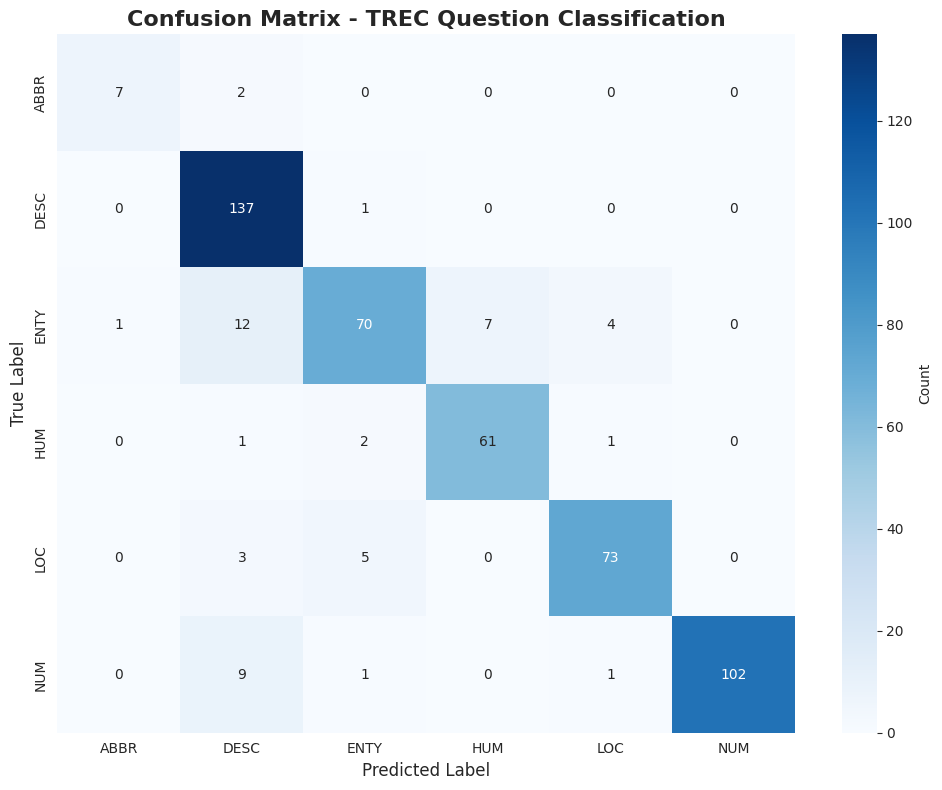

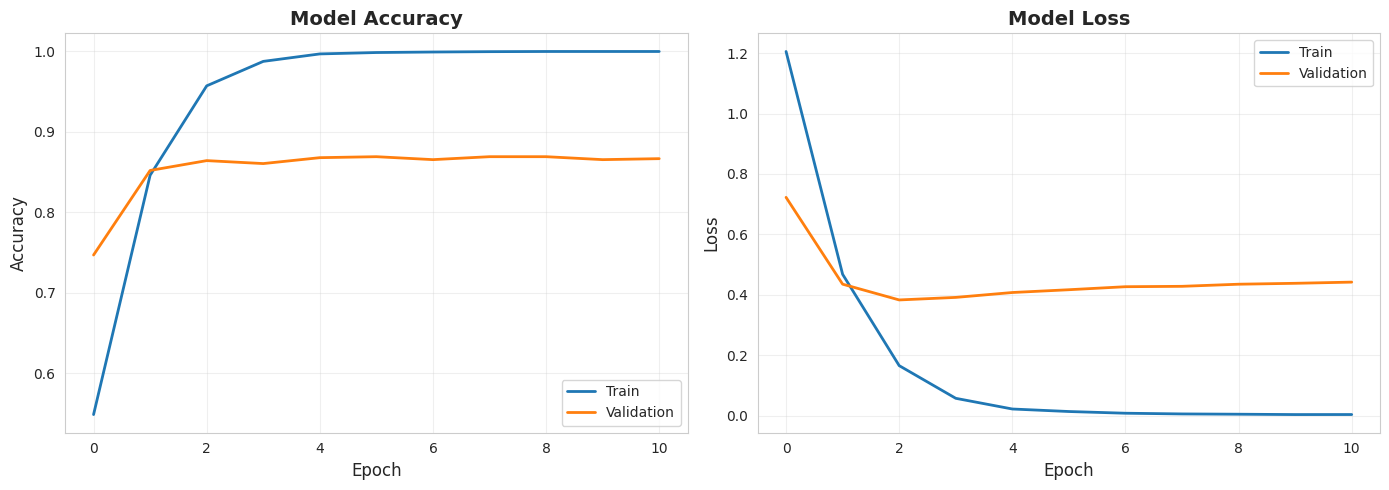

In [ ]:

# 8. VISUALIZATION


# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - TREC Question Classification', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Plot Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ĐÁNH GIÁ VÀ NHẬN XÉT KẾT QUẢ MÔ HÌNH

## TỔNG QUAN HIỆU SUẤT

### Kết quả tổng thể:
- Test Accuracy: 90.00% - Mô hình dự đoán chính xác 90% các câu hỏi
- F1 Score (Macro): 0.8864 - Điểm trung bình cân bằng giữa Precision và Recall
- F1 Score (Weighted): 0.8989 - Điểm F1 có trọng số theo số lượng mẫu mỗi lớp

## PHÂN TÍCH CHI TIẾT THEO TỪNG LOẠI CÂU HỎI

### Loại câu hỏi hoạt động TỐT NHẤT:

1. NUM (Numeric - Số) - F1: 0.9488
   - Precision: 1.0000 (Hoàn hảo - không dự đoán nhầm)
   - Recall: 0.9027 (Nhận diện được 90.27% câu hỏi số)
   - Support: 113 mẫu
   - Nhận xét: Mô hình xuất sắc trong việc phân loại câu hỏi yêu cầu trả lời bằng số

2. LOC (Location - Địa điểm) - F1: 0.9125
   - Precision: 0.9241
   - Recall: 0.9012
   - Support: 81 mẫu
   - Nhận xét: Hiệu suất cao, cân bằng tốt giữa precision và recall

3. HUM (Human - Con người) - F1: 0.9173
   - Precision: 0.8971
   - Recall: 0.9385
   - Support: 65 mẫu
   - Nhận xét: Recall cao cho thấy ít bỏ sót câu hỏi về con người

4. DESC (Description - Mô tả) - F1: 0.9073
   - Precision: 0.8354
   - Recall: 0.9928 (Cao nhất)
   - Support: 138 mẫu (Nhiều nhất)
   - Nhận xét: Recall rất cao nhưng precision thấp hơn, có xu hướng dự đoán DESC nhiều hơn thực tế

### Loại câu hỏi cần CẢI THIỆN:

5. ABBR (Abbreviation - Viết tắt) - F1: 0.8235
   - Precision: 0.8750
   - Recall: 0.7778 (Thấp nhất)
   - Support: 9 mẫu (Rất ít)
   - Vấn đề:
     - Dữ liệu không cân bằng (chỉ 9 mẫu)
     - Bỏ sót 22.22% câu hỏi viết tắt
   - Giải pháp: Cần tăng cường dữ liệu training cho lớp này

6. ENTY (Entity - Thực thể) - F1: 0.8092
   - Precision: 0.8861
   - Recall: 0.7447 (Thấp thứ 2)
   - Support: 94 mẫu
   - Vấn đề:
     - Bỏ sót 25.53% câu hỏi về thực thể
     - Có thể nhầm lẫn với DESC hoặc HUM
   - Giải pháp: Cần phân tích confusion matrix để xem nhầm với lớp nào

## PHÂN TÍCH CONFUSION MATRIX

### Các trường hợp nhầm lẫn đáng chú ý:

1. ABBR (hàng 1): 7 đúng, 2 nhầm thành DESC
   - Viết tắt đôi khi được hiểu nhầm là yêu cầu mô tả

2. DESC (hàng 2): 137/138 đúng (Xuất sắc)
   - Chỉ nhầm 1 mẫu thành ENTY

3. ENTY (hàng 3): 70 đúng, nhưng:
   - 12 nhầm thành DESC (Lớn nhất)
   - 7 nhầm thành HUM
   - 4 nhầm thành LOC
   - Nguyên nhân: ENTY có đặc điểm chồng chéo với nhiều lớp khác

4. NUM (hàng 6): 102/113 đúng
   - 9 nhầm thành DESC
   - Một số câu hỏi số có thể chứa từ khóa mô tả

## KẾT LUẬN VÀ KHUYẾN NGHỊ

### Điểm mạnh:
1. Độ chính xác tổng thể cao (90%)
2. Hoạt động xuất sắc với câu hỏi NUM, LOC, HUM
3. Recall cao với DESC (99.28%)
4. Mô hình ổn định với weighted F1 = 0.8989

### Điểm yếu:
1. Hiệu suất thấp với ABBR do dữ liệu không cân bằng
2. ENTY dễ nhầm lẫn với các lớp khác
3. DESC có xu hướng bị over-predicted

### Đề xuất cải thiện trong thời gian tới:

1. Tăng cường dữ liệu:
   - Thu thập thêm câu hỏi ABBR và ENTY
   - Sử dụng data augmentation (back-translation, synonym replacement)
   - Áp dụng class_weight trong model.fit() để cân bằng

2. Tối ưu mô hình:
   - Thử các kiến trúc sâu hơn (Bi-LSTM, BERT)
   - Fine-tune hyperparameters (learning rate, dropout rate, number of filters)
   - Thêm attention mechanism để focus vào từ khóa quan trọng

3. Feature engineering:
   - Thêm đặc trưng từ khóa đặc biệt (What, Who, When, Where, Why, How)
   - Sử dụng pre-trained embeddings (GloVe, Word2Vec, FastText)
   - Tạo thêm features từ vị trí của từ trong câu

4. Xử lý nhầm lẫn ENTY-DESC:
   - Phân tích sâu các mẫu nhầm lẫn
   - Thêm rules hoặc post-processing logic
   - Tăng cường đặc trưng phân biệt giữa entity và description

## ĐÁNH GIÁ CUỐI CÙNG:

Với accuracy 90% và F1-weighted 0.8989, mô hình này được đánh giá KHÁ TỐT cho bài toán phân loại câu hỏi 6 lớp. Đây là kết quả chấp nhận được cho một mô hình CNN baseline, đặc biệt khi xử lý dữ liệu không cân bằng. Tuy nhiên, vẫn còn nhiều không gian để cải thiện, đặc biệt với các lớp thiểu số như ABBR và ENTY.

Mức độ sẵn sàng triển khai:
- Phù hợp cho prototype và demo
- Cần cải thiện trước khi đưa vào production (đặc biệt là ABBR)
- Mục tiêu tiếp theo: Đạt F1 score trên 0.95 cho tất cả các lớp

In [ ]:

# 8. PREDICTION FUNCTION


def predict_question(question):
    """
    Dự đoán loại câu hỏi

    Args:
        question (str): Câu hỏi cần phân loại

    Returns:
        tuple: (predicted_label, confidence, all_probabilities)
    """
    # Preprocess
    question = preprocess_text(question)

    # Tokenize và pad
    seq = tokenizer.texts_to_sequences([question])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post')

    # Predict
    pred = model.predict(padded, verbose=0)
    class_idx = np.argmax(pred[0])
    confidence = pred[0][class_idx]

    return label_names[class_idx], confidence, pred[0]



In [ ]:

# 9. DEMO PREDICTIONS



print(" DEMO PREDICTIONS")


demo_questions = [
    "What does NASA stand for?",
    "Who invented the telephone?",
    "Where is the Eiffel Tower located?",
    "How many planets are in our solar system?",
    "What is a hurricane?",
    "How does photosynthesis work?",
    "When did World War II end?",
    "Why is the sky blue?",

]

for q in demo_questions:
    pred_label, conf, probs = predict_question(q)
    print(f"\n Question: {q}")
    print(f" Predicted: {pred_label} ({label_descriptions[pred_label]})")
    print(f"   Confidence: {conf*100:.2f}%")

    # Show top 3 predictions
    top3_idx = np.argsort(probs)[-3:][::-1]
    print("   Top 3:")
    for idx in top3_idx:
        print(f"      {label_names[idx]}: {probs[idx]*100:.2f}%")


 DEMO PREDICTIONS

 Question: What does NASA stand for?
 Predicted: ABBR (Abbreviation (Từ viết tắt))
   Confidence: 99.60%
   Top 3:
      ABBR: 99.60%
      DESC: 0.17%
      HUM: 0.07%

 Question: Who invented the telephone?
 Predicted: HUM (Human (Con người))
   Confidence: 99.86%
   Top 3:
      HUM: 99.86%
      ENTY: 0.04%
      LOC: 0.04%

 Question: Where is the Eiffel Tower located?
 Predicted: LOC (Location (Địa điểm))
   Confidence: 99.50%
   Top 3:
      LOC: 99.50%
      NUM: 0.24%
      DESC: 0.17%

 Question: How many planets are in our solar system?
 Predicted: NUM (Numeric (Số học))
   Confidence: 99.96%
   Top 3:
      NUM: 99.96%
      DESC: 0.03%
      ABBR: 0.00%

 Question: What is a hurricane?
 Predicted: DESC (Description (Mô tả))
   Confidence: 80.51%
   Top 3:
      DESC: 80.51%
      ENTY: 15.22%
      ABBR: 3.14%

 Question: How does photosynthesis work?
 Predicted: DESC (Description (Mô tả))
   Confidence: 99.22%
   Top 3:
      DESC: 99.22%
      ABBR: 0.

In [ ]:



# 10. test câu hỏi


print("\n" )
print(" THÊM CÂU HỎI VÀO ĐÂY:")


#  THÊM câu hỏi muốn test  VÀO LIST
my_questions = [
    "What is machine learning?",
    "Who is the president of Vietnam?",
    "How are you?"
    "What do you think"

]

if my_questions and my_questions[0]:  # Check if có câu hỏi
    for q in my_questions:
        if q:  # Skip empty strings
            pred_label, conf, probs = predict_question(q)
            print(f"\n Question: {q}")
            print(f" Predicted: {pred_label} ({label_descriptions[pred_label]})")
            print(f"   Confidence: {conf*100:.2f}%")
else:
    print("\n Thêm câu hỏi vào biến 'my_questions' ở trên để test!")

print(" HOÀN THÀNH!")

print(f"\nFinal Results:")
print(f"  • Test Accuracy: {accuracy*100:.2f}%")
print(f"  • F1 Score (Macro): {f1_macro:.4f}")
print(f"  • F1 Score (Weighted): {f1_weighted:.4f}")



 THÊM CÂU HỎI VÀO ĐÂY:

 Question: What is machine learning?
 Predicted: DESC (Description (Mô tả))
   Confidence: 81.02%

 Question: Who is the president of Vietnam?
 Predicted: HUM (Human (Con người))
   Confidence: 99.78%

 Question: How are you?What do you think
 Predicted: DESC (Description (Mô tả))
   Confidence: 99.81%
 HOÀN THÀNH!

Final Results:
  • Test Accuracy: 89.40%
  • F1 Score (Macro): 0.8887
  • F1 Score (Weighted): 0.8931
